# CareAssist - Light GBM Prediction Model
**Train on real AFCARS FY2020-2024 data (5 years)**

In [ ]:
# Cell 1: Install packages
!pip install lightgbm 
!pip install -q xgboost shap imbalanced-learn

In [ ]:
# Cell 2: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json, os, glob, zipfile
warnings.filterwarnings("ignore")


from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve
)
import xgboost as xgb
import shap
import joblib
from imblearn.over_sampling import SMOTE
from pathlib import Path

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
print("All imports OK")

All imports OK


In [10]:
# Cell 3: Load CSV files (excluding 2019)
DATA_DIR = Path("/Users/courtneychen/Library/CloudStorage/Box-Box/capstone/data")

dfs = []
for year in range(2020, 2025):
    temp_df = pd.read_parquet(DATA_DIR / f"afcars_{year}.parquet")
    dfs.append(temp_df)

df = pd.concat(dfs, ignore_index=True)
del dfs
df.head()

,FY,Version,STATE,St,REPDATYR,REPDATMO,FIPSCode,RecNumbr,SEX,AMIAKN,...,Entered,Exited,Served,IsWaiting,IsTPR,AgedOut,RaceEthn,Race,StFCID,year
0,2020,1,37,NC,2020,9,8,R99044225246,2.0,1.0,...,1,0,1,0,0,0,3,3,NCR99044225246,2020
1,2020,1,37,NC,2020,9,8,R99044231032,1.0,0.0,...,0,0,1,0,0,0,1,1,NCR99044231032,2020
2,2020,1,37,NC,2020,9,37051,R99044231063,1.0,0.0,...,0,0,1,0,0,0,99,99,NCR99044231063,2020
3,2020,1,37,NC,2020,9,8,R99044232374,2.0,0.0,...,1,0,1,0,0,0,1,1,NCR99044232374,2020
4,2020,1,37,NC,2020,9,8,R99044238028,1.0,0.0,...,0,0,1,0,0,0,1,1,NCR99044238028,2020


In [ ]:
# Cell 4: Define target variable
# Disrupted = discharge reason Transfer(6)/Runaway(7) OR 3+ placements
# NUMPLEP excluded from features to avoid data leakage

DISRUPTION_CODES = {6, 7}

def label_disruption(row):
    d = row["DISREASN"]
    n = row["NUMPLEP"]
    if pd.notna(d) and int(d) in DISRUPTION_CODES:
        return 1
    if pd.notna(n) and int(n) >= 3:
        return 1
    return 0

df["disruption"] = df.apply(label_disruption, axis=1)
pos = df["disruption"].sum()
print(f"Disrupted: {pos:,} ({100*pos/len(df):.1f}%)")
print(f"Stable:    {len(df)-pos:,} ({100*(len(df)-pos)/len(df):.1f}%)")
print("\nBy fiscal year:")
print(df.groupby("FY")["disruption"].agg(["count","mean","sum"]).to_string())

Disrupted: 1,036,684 (36.0%)
Stable:    1,842,474 (64.0%)

By fiscal year:
       count      mean     sum
FY                            
2020  632684  0.344643  218050
2021  605932  0.344082  208490
2022  569871  0.344541  196344
2023  548827  0.385284  211454
2024  521844  0.387752  202346


In [ ]:
# Cell 5: Feature engineering
df["age_at_removal"] = df["AgeAtLatRem"].where(df["AgeAtLatRem"] < 99)

disability_cols = ["MR", "VISHEAR", "PHYDIS", "EmotDist", "OTHERMED"]
for c in disability_cols:
    df[c] = df[c].fillna(0).clip(0, 1).astype(int)
df["has_disability"] = df[disability_cols].max(axis=1)
df["has_clinical_disability"] = (df["CLINDIS"] == 1).astype(int)
df["has_behavioral"] = df["CHBEHPRB"].fillna(0).clip(0, 1).astype(int)

removal_reason_cols = [
    "PHYABUSE","SEXABUSE","NEGLECT","AAPARENT","DAPARENT",
    "AACHILD","DACHILD","CHILDIS","PRTSDIED","PRTSJAIL",
    "NOCOPE","ABANDMNT","RELINQSH","HOUSING"
]
for c in removal_reason_cols:
    df[c] = df[c].fillna(0).clip(0, 1).astype(int)
df["num_removal_reasons"] = df[removal_reason_cols].sum(axis=1)

df["placement_type"] = df["CURPLSET"].where(df["CURPLSET"].isin([1,2,3,4,5,6,7,8]))
df["case_goal"] = df["CASEGOAL"].where(df["CASEGOAL"].isin([1,2,3,4,5,6,7]))
df["total_removals"] = df["TOTALREM"].where(df["TOTALREM"] < 98)

if "SettingLOS" in df.columns:
    df["los_current_setting"] = pd.to_numeric(df["SettingLOS"], errors="coerce")
else:
    df["los_current_setting"] = np.nan
if "LatRemLOS" in df.columns:
    df["los_latest_removal"] = pd.to_numeric(df["LatRemLOS"], errors="coerce")
else:
    df["los_latest_removal"] = np.nan

df["ever_adopted"] = df["EVERADPT"].fillna(0).clip(0, 1).astype(int)
df["mandatory_removal"] = df["MANREM"].fillna(0).clip(0, 1).astype(int)

FEATURE_COLS = [
    "age_at_removal",
    "total_removals","placement_type","case_goal",
    "has_disability","has_clinical_disability","has_behavioral",
    "num_removal_reasons",
    "PHYABUSE","SEXABUSE","NEGLECT","AAPARENT","DAPARENT",
    "NOCOPE","ABANDMNT","HOUSING",
    "los_current_setting","los_latest_removal",
    "ever_adopted","mandatory_removal",
]
print(f"{len(FEATURE_COLS)} features (race, gender, NUMPLEP excluded)")

20 features (race, gender, NUMPLEP excluded)


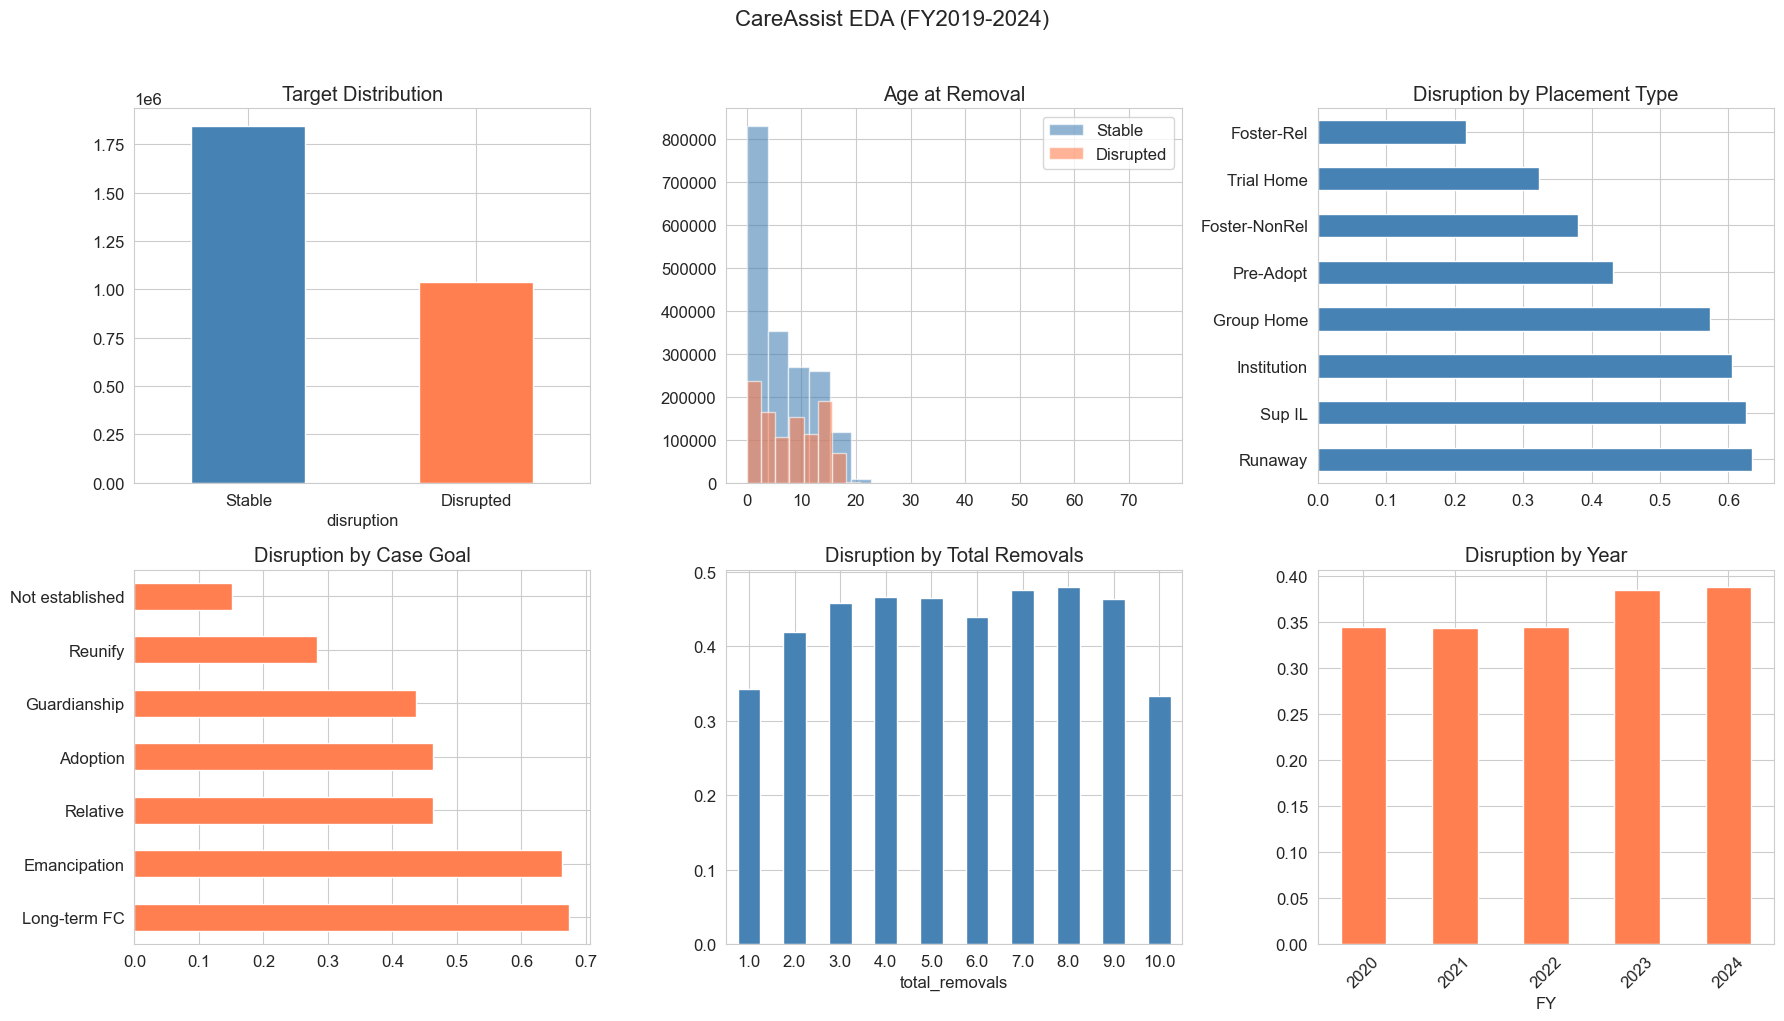

In [ ]:
# Cell 6: EDA
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

df["disruption"].value_counts().plot(kind="bar", ax=axes[0,0], color=["steelblue","coral"])
axes[0,0].set_title("Target Distribution")
axes[0,0].set_xticklabels(["Stable","Disrupted"], rotation=0)

df[df["disruption"]==0]["age_at_removal"].hist(bins=20, ax=axes[0,1], alpha=0.6, label="Stable", color="steelblue")
df[df["disruption"]==1]["age_at_removal"].hist(bins=20, ax=axes[0,1], alpha=0.6, label="Disrupted", color="coral")
axes[0,1].set_title("Age at Removal"); axes[0,1].legend()

pt_labels = {1:"Pre-Adopt",2:"Foster-Rel",3:"Foster-NonRel",4:"Group Home",5:"Institution",6:"Sup IL",7:"Runaway",8:"Trial Home"}
pt_rates = df.groupby("placement_type")["disruption"].mean().sort_values(ascending=False)
pt_rates.index = [pt_labels.get(int(i),str(i)) for i in pt_rates.index]
pt_rates.plot(kind="barh", ax=axes[0,2], color="steelblue")
axes[0,2].set_title("Disruption by Placement Type")

cg_labels = {1:"Reunify",2:"Relative",3:"Adoption",4:"Long-term FC",5:"Emancipation",6:"Guardianship",7:"Not established"}
cg_rates = df.groupby("case_goal")["disruption"].mean().sort_values(ascending=False)
cg_rates.index = [cg_labels.get(int(i),str(i)) for i in cg_rates.index]
cg_rates.plot(kind="barh", ax=axes[1,0], color="coral")
axes[1,0].set_title("Disruption by Case Goal")

tr = df.groupby("total_removals")["disruption"].mean().head(10)
tr.plot(kind="bar", ax=axes[1,1], color="steelblue")
axes[1,1].set_title("Disruption by Total Removals")
axes[1,1].tick_params(axis="x", rotation=0)

yr = df.groupby("FY")["disruption"].mean()
yr.plot(kind="bar", ax=axes[1,2], color="coral")
axes[1,2].set_title("Disruption by Year")
axes[1,2].tick_params(axis="x", rotation=45)

plt.suptitle("CareAssist EDA (FY2019-2024)", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Cell 7: Prepare data
model_df = df[FEATURE_COLS + ["disruption"]].copy()
cat_cols = ["placement_type","case_goal"]
model_df = pd.get_dummies(model_df, columns=cat_cols, prefix=cat_cols, dummy_na=False)

y = model_df["disruption"]
X = model_df.drop(columns=["disruption"])
feature_names = list(X.columns)
print(f"Features: {len(feature_names)}, Records: {len(X):,}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Median imputation
for c in X_train.columns:
    median = X_train[c].median()
    X_train[c] = X_train[c].fillna(median)
    X_test[c] = X_test[c].fillna(median)

print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")
print(f"Disruption rate: train={y_train.mean():.3f} test={y_test.mean():.3f}")
print("Skipping SMOTE — 36% positive rate is balanced enough")

Features: 33, Records: 2,879,158
Train: 2,303,326  Test: 575,832
Disruption rate: train=0.360 test=0.360
Skipping SMOTE — 36% positive rate is balanced enough


In [ ]:
# Cell 8: LightGBM
print("Training LightGBM...")

# Experimented with some different hyperparameters but gains were minimal
lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

lgbm.fit(X_train, y_train)

lgbm_proba = lgbm.predict_proba(X_test)[:, 1]
lgbm_auc = roc_auc_score(y_test, lgbm_proba)
lgbm_ap = average_precision_score(y_test, lgbm_proba)

print(f"  ROC-AUC: {lgbm_auc:.4f}  Avg Precision: {lgbm_ap:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.0 MB/s eta 0:00:00
Training LightGBM...
[LightGBM] [Info] Number of positive: 829347, number of negative: 1473979
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.078066 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 614
[LightGBM] [Info] Number of data points in the train set: 2303326, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.360065 -> initscore=-0.575082
[LightGBM] [Info] Start training from score -0.575082
  ROC-AUC: 0.9007  Avg Precision: 0.8298


In [ ]:
# Cell 9: XGBoost
print("Training XGBoost...")
neg, pos_count = (y_train==0).sum(), (y_train==1).sum()
scale_pos = neg / max(pos_count, 1)
xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos,
    tree_method="hist", eval_metric="logloss",
    random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train, verbose=False)
xgb_proba = xgb_model.predict_proba(X_test)[:,1]
xgb_auc = roc_auc_score(y_test, xgb_proba)
xgb_ap = average_precision_score(y_test, xgb_proba)
print(f"  ROC-AUC: {xgb_auc:.4f}  Avg Precision: {xgb_ap:.4f}")

if xgb_auc > lgbm_auc:
    best_model, best_proba, best_name, best_auc = xgb_model, xgb_proba, "XGBoost", xgb_auc
else:
    best_model, best_proba, best_name, best_auc = lgbm, lgbm_proba, "LightGBM", lgbm_auc
print(f"\nBest: {best_name} (AUC={best_auc:.4f})")

Training XGBoost...
  ROC-AUC: 0.9041  Avg Precision: 0.8349

Best: XGBoost (AUC=0.9041)


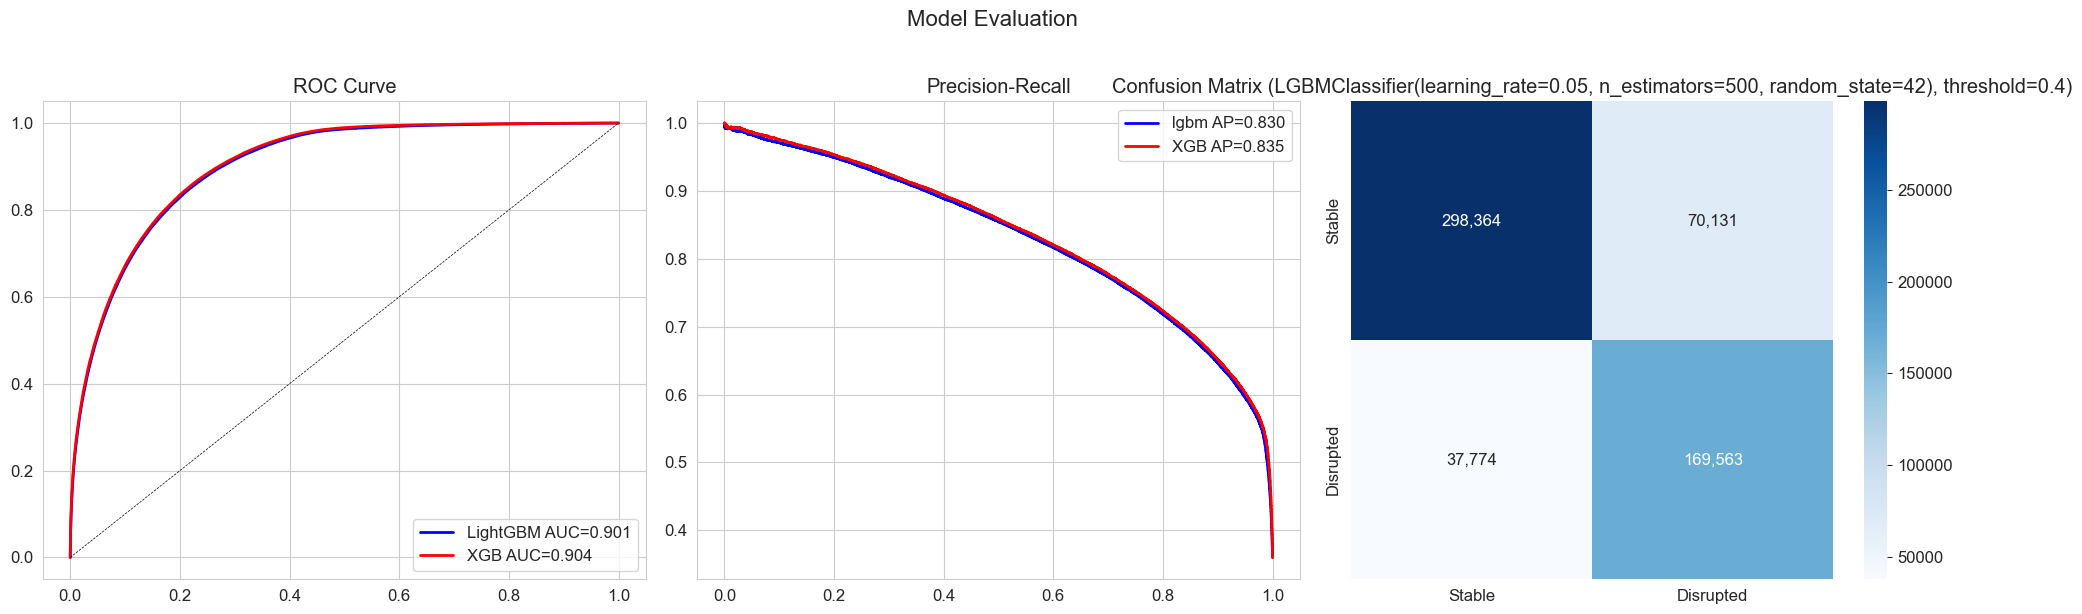

              precision    recall  f1-score   support

      Stable       0.89      0.81      0.85    368495
   Disrupted       0.71      0.82      0.76    207337

    accuracy                           0.81    575832
   macro avg       0.80      0.81      0.80    575832
weighted avg       0.82      0.81      0.82    575832



In [41]:
# Cell 10: Evaluation plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, lgbm_proba)
fpr_xg, tpr_xg, _ = roc_curve(y_test, xgb_proba)
axes[0].plot(fpr_lgbm, tpr_lgbm, "b-", lw=2, label=f"LightGBM AUC={lgbm_auc:.3f}")
axes[0].plot(fpr_xg, tpr_xg, "r-", lw=2, label=f"XGB AUC={xgb_auc:.3f}")
axes[0].plot([0,1],[0,1],"k--",lw=0.5)
axes[0].set_title("ROC Curve"); axes[0].legend()

p_lgbm, r_lgbm, _ = precision_recall_curve(y_test, lgbm_proba)
p_xg, r_xg, _ = precision_recall_curve(y_test, xgb_proba)
axes[1].plot(r_lgbm, p_lgbm, "b-", lw=2, label=f"lgbm AP={lgbm_ap:.3f}")
axes[1].plot(r_xg, p_xg, "r-", lw=2, label=f"XGB AP={xgb_ap:.3f}")
axes[1].set_title("Precision-Recall"); axes[1].legend()

y_pred = (lgbm_proba >= 0.4).astype(int)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
    xticklabels=["Stable","Disrupted"], yticklabels=["Stable","Disrupted"], ax=axes[2])
axes[2].set_title(f"Confusion Matrix ({lgbm}, threshold=0.4)")

plt.suptitle("Model Evaluation", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print(classification_report(y_test, y_pred, target_names=["Stable","Disrupted"]))

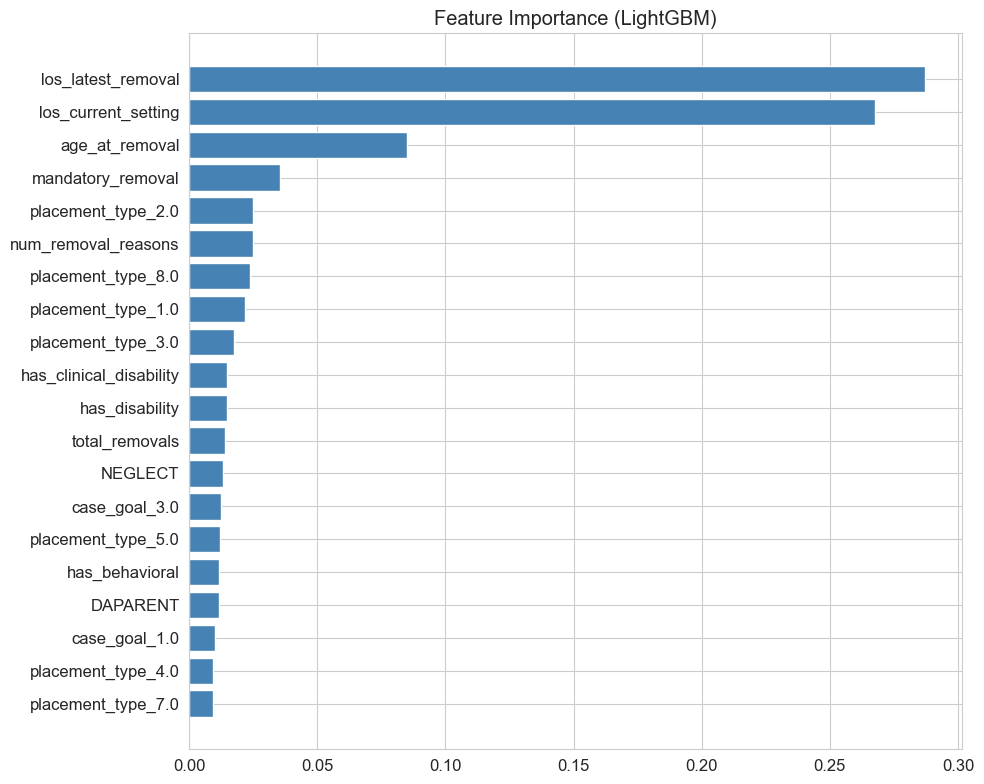

                feature  importance
     los_latest_removal    0.287133
    los_current_setting    0.267667
         age_at_removal    0.085133
      mandatory_removal    0.035600
     placement_type_2.0    0.024733
    num_removal_reasons    0.024733
     placement_type_8.0    0.023600
     placement_type_1.0    0.021867
     placement_type_3.0    0.017467
has_clinical_disability    0.014867
         has_disability    0.014733
         total_removals    0.013800
                NEGLECT    0.013000
          case_goal_3.0    0.012267
     placement_type_5.0    0.012200
         has_behavioral    0.011667
               DAPARENT    0.011600
          case_goal_1.0    0.009933
     placement_type_4.0    0.009467
     placement_type_7.0    0.009333


In [36]:
# Cell 11: Feature importance
feat_imp = pd.DataFrame({"feature":feature_names, "importance":lgbm.feature_importances_}
    ).sort_values("importance", ascending=False)

feat_imp["importance"] = feat_imp["importance"] / feat_imp["importance"].sum()

fig, ax = plt.subplots(figsize=(10, 8))
top20 = feat_imp.head(20)
ax.barh(range(len(top20)), top20["importance"].values, color="steelblue")
ax.set_yticks(range(len(top20))); ax.set_yticklabels(top20["feature"].values)
ax.invert_yaxis(); ax.set_title(f"Feature Importance (LightGBM)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(feat_imp.head(20).to_string(index=False))

Computing SHAP (sample=1000)...


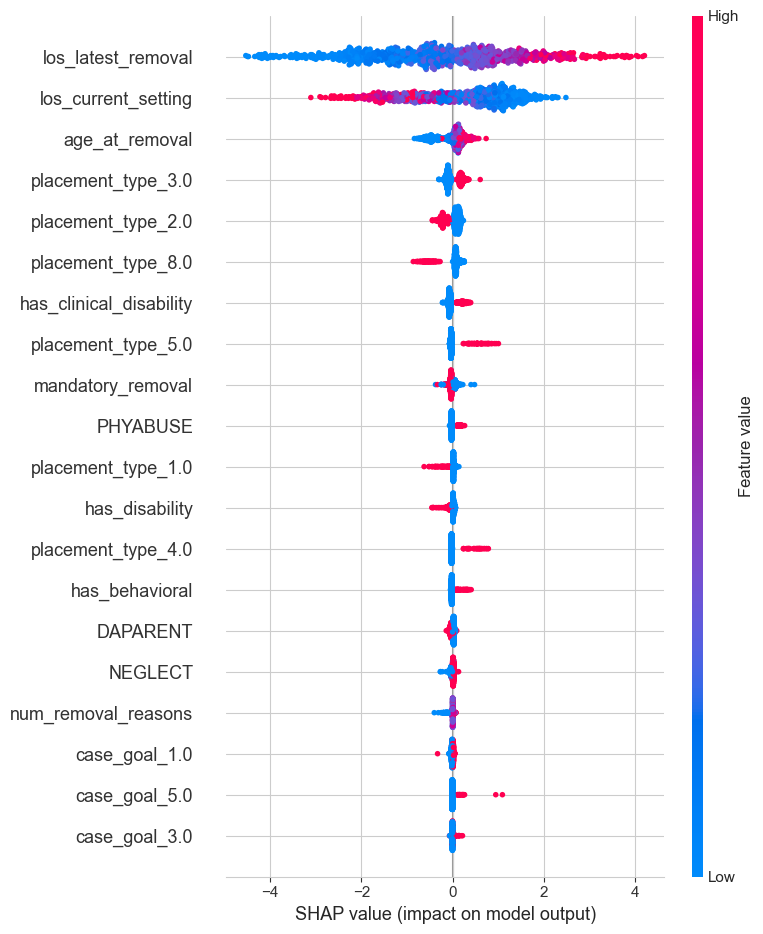

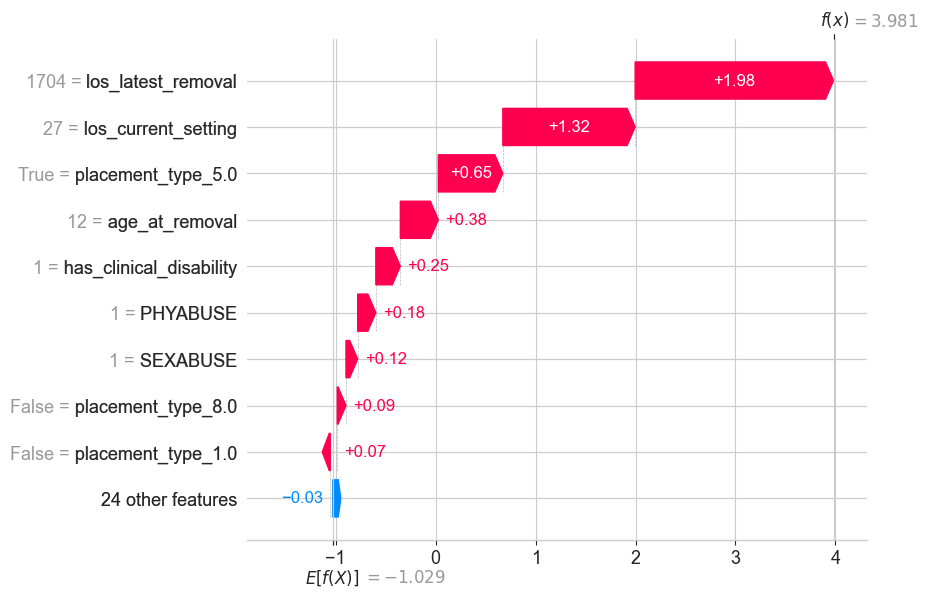

SHAP done


In [37]:
# Cell 12: SHAP
print("Computing SHAP (sample=1000)...")
explainer = shap.TreeExplainer(lgbm)
X_sample = X_test.sample(min(1000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)
if isinstance(shap_values, list): shap_values = shap_values[1]

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False, max_display=20)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

idx = np.argmax(lgbm.predict_proba(X_sample)[:,1])
ev = explainer.expected_value
if isinstance(ev, list): ev = ev[1]
shap.plots.waterfall(shap.Explanation(
    values=shap_values[idx], base_values=ev,
    data=X_sample.iloc[idx], feature_names=feature_names), show=True)
print("SHAP done")

Scoring all records...
Risk Tier Distribution:
    Critical:  419,126 (14.6%)
        High:  413,014 (14.3%)
      Medium:  558,097 (19.4%)
         Low: 1,488,921 (51.7%)


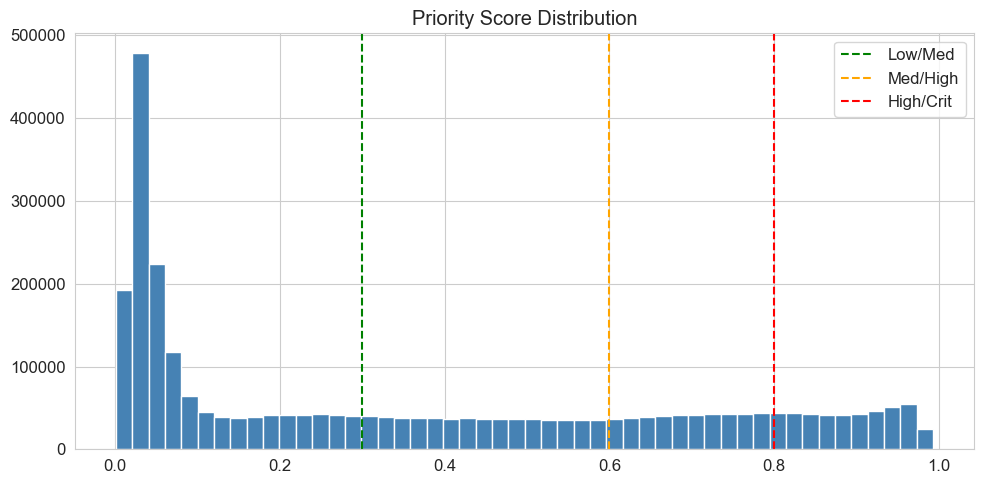

In [38]:
# Cell 13: Score all records
print("Scoring all records...")
X_all = model_df.drop(columns=["disruption"])
df["priority_score"] = lgbm.predict_proba(X_all)[:,1]
df["risk_tier"] = pd.cut(df["priority_score"],
    bins=[0,0.3,0.6,0.8,1.0], labels=["Low","Medium","High","Critical"], include_lowest=True)

print("Risk Tier Distribution:")
tier_dist = df["risk_tier"].value_counts()
for t in ["Critical","High","Medium","Low"]:
    if t in tier_dist.index:
        print(f"  {t:>10}: {tier_dist[t]:>8,} ({100*tier_dist[t]/len(df):.1f}%)")

fig, ax = plt.subplots(figsize=(10,5))
ax.hist(df["priority_score"], bins=50, color="steelblue", edgecolor="white")
for v,c,l in [(0.3,"green","Low/Med"),(0.6,"orange","Med/High"),(0.8,"red","High/Crit")]:
    ax.axvline(v, color=c, ls="--", label=l)
ax.set_title("Priority Score Distribution"); ax.legend()
plt.tight_layout()
plt.savefig("score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [39]:
# Cell 14: Model Output
print("="*60)
print("Model Output")
print("="*60)
print(f"LGBM_AUC={lgbm_auc:.4f}")
print(f"XGB_AUC={xgb_auc:.4f}")
print(f"TOTAL_RECORDS={len(df):,}")
print(f"DISRUPTION_RATE={y.mean():.4f}")
print(f"FEATURES={len(feature_names)}")
print(f"TRAIN_SAMPLES={len(X_train):,}")
print(f"TEST_SAMPLES={len(X_test):,}")
print(f'YEARS={sorted(df["FY"].dropna().unique().tolist())}')
print(f"\nTIER_DISTRIBUTION:")
for t in ["Critical","High","Medium","Low"]:
    if t in tier_dist.index: print(f"  {t}: {tier_dist[t]:,}")
print(f"\nTOP_10_FEATURES:")
for _,r in feat_imp.head(10).iterrows():
    print(f'  {r["feature"]}: {r["importance"]:.4f}')
print(f"\nCLASSIFICATION_REPORT:")
print(classification_report(y_test, y_pred, target_names=["Stable","Disrupted"]))
cm = confusion_matrix(y_test, y_pred)
print(f"CONFUSION_MATRIX: TN={cm[0,0]:,} FP={cm[0,1]:,} FN={cm[1,0]:,} TP={cm[1,1]:,}")
print("="*60)

Model Output
LGBM_AUC=0.9010
XGB_AUC=0.9041
TOTAL_RECORDS=2,879,158
DISRUPTION_RATE=0.3601
FEATURES=33
TRAIN_SAMPLES=2,303,326
TEST_SAMPLES=575,832
YEARS=[2020, 2021, 2022, 2023, 2024]

TIER_DISTRIBUTION:
  Critical: 419,126
  High: 413,014
  Medium: 558,097
  Low: 1,488,921

TOP_10_FEATURES:
  los_latest_removal: 0.2871
  los_current_setting: 0.2677
  age_at_removal: 0.0851
  mandatory_removal: 0.0356
  placement_type_2.0: 0.0247
  num_removal_reasons: 0.0247
  placement_type_8.0: 0.0236
  placement_type_1.0: 0.0219
  placement_type_3.0: 0.0175
  has_clinical_disability: 0.0149

CLASSIFICATION_REPORT:
              precision    recall  f1-score   support

      Stable       0.93      0.72      0.81    368495
   Disrupted       0.64      0.91      0.75    207337

    accuracy                           0.79    575832
   macro avg       0.79      0.81      0.78    575832
weighted avg       0.83      0.79      0.79    575832

CONFUSION_MATRIX: TN=264,091 FP=104,404 FN=18,784 TP=188,553
